# Prep

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import onnx
from pathlib import Path

BASE_DIR = Path.cwd().resolve()
RFDETR_DIR = (BASE_DIR / ".." / "models" / "rfdetr").resolve()
YOLOV11_DIR = (BASE_DIR / ".." / "models" / "yolov11").resolve()
YOLOV12_DIR = (BASE_DIR / ".." / "models" / "yolov12").resolve()

rfdetr_csv = RFDETR_DIR / "rfdetr_metrics.csv"
yolov11_csv = YOLOV11_DIR / "yolo_metrics.csv"
yolov12_csv = YOLOV12_DIR / "yolo_metrics.csv"

pd.options.display.float_format = '{:.4f}'.format 

In [ ]:
yolov12_csv = YOLOV12_DIR / "yolo_metrics.csv"

pd.options.display.float_format = '{:.4f}'.format 

# Metrics Compariosn

In [175]:
rfd_df = pd.read_csv(rfdetr_csv)
yolov11_df = pd.read_csv(yolov11_csv)
yolov12_df = pd.read_csv(yolov12_csv)

# Standardize column names
rename_map = {
    'mAP50': 'map50', 'map@50': 'map50', 'map_50': 'map50',
    'mAP50-95': 'map50_95', 'map50-95': 'map50_95', 'mAP50_95': 'map50_95', 'map_50_95': 'map50_95',
    'Precision': 'precision', 'Recall': 'recall'
}
for df in (rfd_df, yolov11_df, yolov12_df):
    df.columns = [rename_map.get(c, c.lower()) for c in df.columns]

# Infer variant column if missing / inconsistent
possible_variant_cols = ['variant','model','name']

def extract_variant(val: str):
    if not isinstance(val, str):
        return None
    low = val.lower()
    # map short codes
    if 'nano' in low or low.endswith('-n') or low.endswith('n'): return 'nano'
    if 'small' in low or low.endswith('-s') or low.endswith('s'): return 'small'
    if 'medium' in low or low.endswith('-m') or low.endswith('m'): return 'medium'
    # fallback patterns
    for k,v in {'n':'nano','s':'small','m':'medium'}.items():
        if low.endswith(k):
            return v
    return None

for arch, df in [('rf-detr', rfd_df), ('yolov11', yolov11_df), ('yolov12', yolov12_df)]:
    # find a source column
    source_val = None
    for col in possible_variant_cols:
        if col in df.columns:
            source_val = col
            break
    if source_val is None:
        # create a dummy variant sequence if absent
        df['variant'] = ['nano','small','medium'][:len(df)]
    else:
        df['variant'] = df[source_val].apply(extract_variant)
        # fill any missing by position if exactly 3 rows
        if df['variant'].isna().any() and len(df) == 3:
            df.loc[df['variant'].isna(),'variant'] = ['nano','small','medium']
    df['arch'] = arch

needed_cols = ['map50','map50_95','precision','recall']
for df in (rfd_df, yolov11_df, yolov12_df):
    for col in needed_cols:
        if col not in df.columns:
            df[col] = pd.NA

# Combine all three architectures: RF-DETR, YOLOv11, and YOLOv12
combined = pd.concat([
    rfd_df[needed_cols + ['variant', 'arch']],
    yolov11_df[needed_cols + ['variant', 'arch']],
    yolov12_df[needed_cols + ['variant', 'arch']]
], ignore_index=True)

# Build a model ID (arch-variant)
combined['model'] = combined['arch'] + '-' + combined['variant']

# Display preview
combined

,map50,map50_95,precision,recall,variant,arch,model
0,0.9132,0.6936,0.8622,0.8500,nano,rf-detr,rf-detr-nano
1,0.9161,0.7003,0.8802,0.8400,small,rf-detr,rf-detr-small
2,0.9271,0.7016,0.8894,0.8500,medium,rf-detr,rf-detr-medium
3,0.8800,0.6953,0.8466,0.8025,nano,yolov11,yolov11-nano
4,0.8916,0.7105,0.8484,0.8381,small,yolov11,yolov11-small
5,0.8976,0.7071,0.8640,0.8398,medium,yolov11,yolov11-medium
6,0.8797,0.6916,0.8591,0.8189,nano,yolov12,yolov12-nano
7,0.8848,0.6960,0.8430,0.8304,small,yolov12,yolov12-small
8,0.8990,0.7215,0.8753,0.8590,medium,yolov12,yolov12-medium


## Visualzation

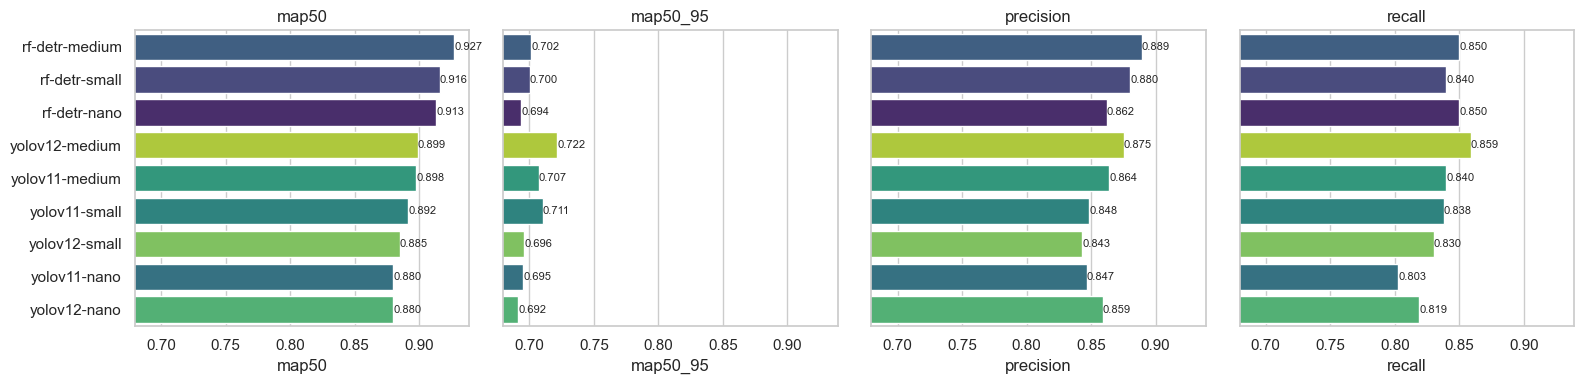

In [176]:
metrics = ['map50','map50_95','precision','recall']
plot_df = combined.melt(id_vars=['model','arch','variant'], value_vars=metrics, var_name='metric', value_name='value')

# Drop rows where all values are NA (unlikely but safe)
plot_df = plot_df.dropna(subset=['value'])

# Compute global min/max for scaling
mn, mx = plot_df['value'].min(), plot_df['value'].max()
rng = mx - mn if mx is not None else 0
# Tight y-range with small margin so similar values are distinguishable
ylim_low = max(0, mn - rng * 0.05)
ylim_high = min(1.0, mx + rng * 0.05)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 4), sharey=True)
for ax, m in zip(axes, metrics):
    sub = combined[['model', m]].dropna()
    order = sub.sort_values(m, ascending=False)['model']
    sns.barplot(data=sub, x=m, y='model', order=order, ax=ax, hue='model', dodge=False, palette='viridis')
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_title(m)
    ax.set_xlabel(m)
    ax.set_ylabel('')
    ax.set_xlim(ylim_low, ylim_high)
    # annotate bars
    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f', fontsize=8)
fig.tight_layout()
plt.show()

## Ranking

In [177]:
# Ranking with composite score 
ranking_df = combined.copy()

# Ensure numeric for map50 and map50_95
for c in ['map50','map50_95']:
    ranking_df[c] = pd.to_numeric(ranking_df[c], errors='coerce')

# Composite score: average of map50 and map50_95 when both exist, else whichever exists
ranking_df['score'] = [
    (m50 + m95) / 2.0 if pd.notna(m50) and pd.notna(m95)
    else (m95 if pd.notna(m95) else m50)
    for m50, m95 in zip(ranking_df['map50'], ranking_df['map50_95'])
]

ranking_df = ranking_df.sort_values('score', ascending=False)
ranking_df[['model','variant','arch','map50','map50_95','precision','recall','score']].reset_index(drop=True)

,model,variant,arch,map50,map50_95,precision,recall,score
0,rf-detr-medium,medium,rf-detr,0.9271,0.7016,0.8894,0.8500,0.8144
1,yolov12-medium,medium,yolov12,0.8990,0.7215,0.8753,0.8590,0.8103
2,rf-detr-small,small,rf-detr,0.9161,0.7003,0.8802,0.8400,0.8082
3,rf-detr-nano,nano,rf-detr,0.9132,0.6936,0.8622,0.8500,0.8034
4,yolov11-medium,medium,yolov11,0.8976,0.7071,0.8640,0.8398,0.8024
5,yolov11-small,small,yolov11,0.8916,0.7105,0.8484,0.8381,0.8010
6,yolov12-small,small,yolov12,0.8848,0.6960,0.8430,0.8304,0.7904
7,yolov11-nano,nano,yolov11,0.8800,0.6953,0.8466,0.8025,0.7876
8,yolov12-nano,nano,yolov12,0.8797,0.6916,0.8591,0.8189,0.7856


## Training Plots

In [ ]:
# Display variant-specific plots in a tidy grid

ROOT = Path("D:/Workspace/Repository/thesis/research/object-detection-engine/models").resolve()
RF_ROOT = ROOT / "rfdetr" / "models"
YOLO11_ROOT = ROOT / "yolov11" / "runs" / "detect"
YOLO12_ROOT = ROOT / "yolov12" / "runs" / "detect"

rf_variants = {
    'nano': RF_ROOT / 'train_nano',
    'small': RF_ROOT / 'train_small',
    'medium': RF_ROOT / 'train_medium'
}

yolov11_variants = {
    'nano': YOLO11_ROOT / 'train_yolov11n' / 'results.png',
    'small': YOLO11_ROOT / 'train_yolov11s' / 'results.png',
    'medium': YOLO11_ROOT / 'train_yolov11m' / 'results.png',
}

yolov12_variants = {
    'nano': YOLO12_ROOT / 'train_yolov12n' / 'results.png',
    'small': YOLO12_ROOT / 'train_yolov12s' / 'results.png',
    'medium': YOLO12_ROOT / 'train_yolov12m' / 'results.png',
}

priority_keywords = ['metrics', 'result', 'eval']

def pick_rf_image(folder: Path):
    if not folder.exists():
        return None
    pngs = list(folder.glob('*.png'))
    if not pngs:
        return None
    for kw in priority_keywords:
        for p in pngs:
            if kw in p.name.lower():
                return p
    return pngs[0]

def pick_yolo_image(path: Path):
    return path if path.exists() else None

rf_images = {v: pick_rf_image(p) for v, p in rf_variants.items()}
yolov11_images = {v: pick_yolo_image(p) for v, p in yolov11_variants.items()}
yolov12_images = {v: pick_yolo_image(p) for v, p in yolov12_variants.items()}

rows = [
    ('RF-DETR', rf_images),
    ('YOLOv11', yolov11_images),
    ('YOLOv12', yolov12_images),
]

# Build a 3 x 3 grid: Row 1 RF-DETR, Row 2 YOLOv11, Row 3 YOLOv12
fig, axes = plt.subplots(len(rows), 3, figsize=(15, 11))
fig.suptitle('Variant Comparison: RF-DETR (top) vs YOLOv11 (middle) vs YOLOv12 (bottom)', fontsize=14)

for row_index, (arch, images) in enumerate(rows):
    for col, variant in enumerate(['nano', 'small', 'medium']):
        ax = axes[row_index, col]
        ax.axis('off')
        img_path = images.get(variant)
        if img_path and img_path.exists():
            try:
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(f"{arch} {variant}", fontsize=11)
            except Exception as e:
                ax.text(0.5, 0.5, f"Error loading\n{img_path.name}\n{e}", ha='center', va='center', fontsize=9)
        else:
            ax.text(0.5, 0.5, f"No image\n({arch} {variant})", ha='center', va='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Quick debug summary (optional - useful to check which images were found)
print("Found images:")
for arch, images in rows:
    print(f"{arch}: {{'nano': {images['nano'].name if images['nano'] else None}, 'small': {images['small'].name if images['small'] else None}, 'medium': {images['medium'].name if images['medium'] else None}}}")

# Inference Time Comparison

In [ ]:
ONNX_CSV = (BASE_DIR / ".." / "onnx_benchmark_results_20251208_004121.csv").resolve()
print(ONNX_CSV)

onnx_df = pd.read_csv(ONNX_CSV)
onnx_df.head()

D:\Workspace\Repository\thesis\research\object-detection-engine\onnx_benchmark_results_20251208_004121.csv


,Model,Input_Size,Phase,Mean,Median,P90,P95,Min,Max
0,YOLOv11-n,416x416,T_pre,1.6639,1.5440,2.2003,2.3800,1.1469,3.1517
1,YOLOv11-n,416x416,T_infer,14.1045,13.5506,16.5023,17.8158,12.1409,19.9208
2,YOLOv11-n,416x416,T_post,0.1730,0.1562,0.2222,0.2445,0.1355,0.3570
3,YOLOv11-n,416x416,T_total,15.9415,15.4600,18.4864,19.7696,13.6891,22.3822
4,YOLOv11-s,416x416,T_pre,1.8042,1.7024,2.2450,2.4199,1.2773,4.0814


In [ ]:
total_df = onnx_df[onnx_df["Phase"] == "T_total"].copy()

# Normalize model naming (optional but keeps it consistent with earlier sections)
def normalize_model_name(m):
    m = str(m)
    # Make RF-DETR, YOLOv11, YOLOv12 consistent with earlier text
    m = (
        m.replace("YOLOv11", "YOLOv11")
         .replace("YOLOv12", "YOLOv12")
         .replace("RF-DETR", "RF-DETR")
    )
    return m

total_df["Model"] = total_df["Model"].apply(normalize_model_name)

# Extract arch and variant so we can align to earlier analysis
def split_arch_variant(m):
    # Examples: "YOLOv11-n", "YOLOv12-m", "RF-DETR-small"
    m = str(m)
    if "RF-DETR" in m:
        arch = "rf-detr"
        variant = m.split("-")[-1]
    elif "YOLOv11" in m:
        arch = "yolov11"
        variant = m.split("-")[-1]
    elif "YOLOv12" in m:
        arch = "yolov12"
        variant = m.split("-")[-1]
    else:
        arch = "unknown"
        variant = m
    return arch, variant

total_df[["arch", "variant"]] = total_df["Model"].apply(
    lambda x: pd.Series(split_arch_variant(x))
)

# Keep key columns
latency_df = total_df[[
    "Model", "arch", "variant", "Input_Size",
    "Mean", "Median", "P90", "P95", "Min", "Max"
]].copy()

latency_df.sort_values("Mean", inplace=True)
latency_df.reset_index(drop=True, inplace=True)
print(latency_df)

,Model,arch,variant,Input_Size,Mean,Median,P90,P95,Min,Max
0,YOLOv11-n,yolov11,n,416x416,15.9415,15.4600,18.4864,19.7696,13.6891,22.3822
1,YOLOv12-n,yolov12,n,416x416,21.7343,21.3154,24.4597,25.3808,18.4734,28.4722
2,YOLOv11-s,yolov11,s,416x416,47.1249,47.4040,48.8575,49.2380,27.9927,70.5604
3,YOLOv12-s,yolov12,s,416x416,61.9740,62.2182,64.3167,64.8565,48.7827,67.7166
4,YOLOv11-m,yolov11,m,416x416,115.3840,128.4546,132.8419,133.8748,77.4579,137.3810
5,YOLOv12-m,yolov12,m,416x416,155.3029,155.4316,159.6746,160.1976,138.1249,163.6768
6,RF-DETR-nano,rf-detr,nano,384x384,157.0940,158.8451,163.1260,164.0012,100.6934,172.2484
7,RF-DETR-small,rf-detr,small,512x512,283.2586,284.3492,293.6683,295.4674,240.8658,303.1016
8,RF-DETR-medium,rf-detr,medium,576x576,408.3639,384.8647,516.5155,536.3241,336.7732,560.9076


## Visualization

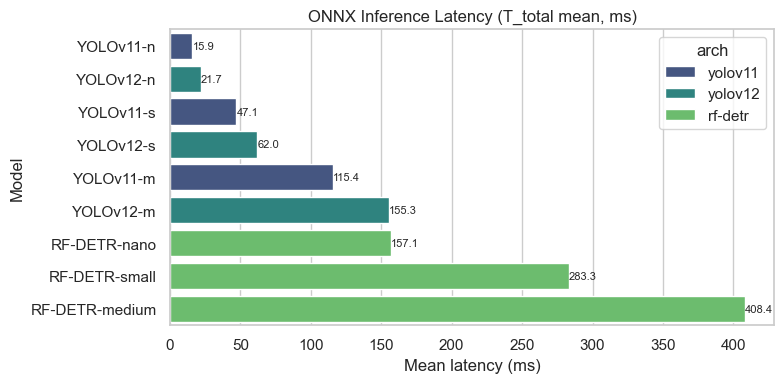

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=latency_df,
    x="Mean",
    y="Model",
    hue="arch",
    dodge=False,
    palette="viridis"
)

ax.set_title("ONNX Inference Latency (T_total mean, ms)")
ax.set_xlabel("Mean latency (ms)")
ax.set_ylabel("Model")
# Annotate bars with exact values
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", fontsize=8)

plt.tight_layout()
plt.show()

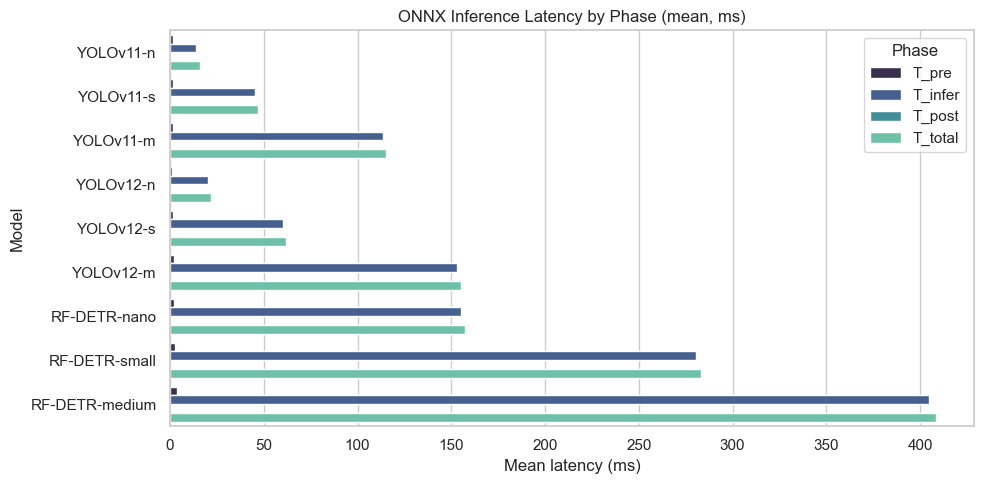

In [ ]:
plt.figure(figsize=(10, 5))
phase_df = onnx_df.copy()
sns.barplot(
    data=phase_df,
    x="Mean",
    y="Model",
    hue="Phase",
    palette="mako"
)
plt.title("ONNX Inference Latency by Phase (mean, ms)")
plt.xlabel("Mean latency (ms)")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## Ranking

In [ ]:
# Rank models by mean total latency (fastest first)
latency_rank = latency_df.copy()
latency_rank["rank"] = latency_rank["Mean"].rank(method="min", ascending=True).astype(int)
latency_rank = latency_rank.sort_values("Mean", ascending=True)

latency_rank[[
    "rank", "Model", "arch", "variant", "Input_Size",
    "Mean", "P90", "P95"
]].reset_index(drop=True)

,rank,Model,arch,variant,Input_Size,Mean,P90,P95
0,1,YOLOv11-n,yolov11,n,416x416,15.9415,18.4864,19.7696
1,2,YOLOv12-n,yolov12,n,416x416,21.7343,24.4597,25.3808
2,3,YOLOv11-s,yolov11,s,416x416,47.1249,48.8575,49.2380
3,4,YOLOv12-s,yolov12,s,416x416,61.9740,64.3167,64.8565
4,5,YOLOv11-m,yolov11,m,416x416,115.3840,132.8419,133.8748
5,6,YOLOv12-m,yolov12,m,416x416,155.3029,159.6746,160.1976
6,7,RF-DETR-nano,rf-detr,nano,384x384,157.0940,163.1260,164.0012
7,8,RF-DETR-small,rf-detr,small,512x512,283.2586,293.6683,295.4674
8,9,RF-DETR-medium,rf-detr,medium,576x576,408.3639,516.5155,536.3241


# Metadata Comparison

In [ ]:
from dataclasses import dataclass

# 1) Point to ONNX model files for each arch/variant
MODELS_ROOT = (BASE_DIR / ".." / "models").resolve()

# Adjust these paths/names to match your actual exported ONNX files
onnx_paths = {
    # YOLOv11
    ("yolov11", "nano"):   MODELS_ROOT / "yolov11" / "yolo11n.sim.onnx",
    ("yolov11", "small"):  MODELS_ROOT / "yolov11" / "yolo11s.sim.onnx",
    ("yolov11", "medium"): MODELS_ROOT / "yolov11" / "yolo11m.sim.onnx",
    # YOLOv12
    ("yolov12", "nano"):   MODELS_ROOT / "yolov12" / "yolov12n.sim.onnx",
    ("yolov12", "small"):  MODELS_ROOT / "yolov12" / "yolov12s.sim.onnx",
    ("yolov12", "medium"): MODELS_ROOT / "yolov12" / "yolov12m.sim.onnx",
    # RF-DETR (update names if different)
    ("rf-detr", "nano"):   MODELS_ROOT / "rfdetr" / "rf_detr_nano.sim.onnx",
    ("rf-detr", "small"):  MODELS_ROOT / "rfdetr" / "rf_detr_small.sim.onnx",
    ("rf-detr", "medium"): MODELS_ROOT / "rfdetr" / "rf_detr_medium.sim.onnx",
}

@dataclass
class ModelMeta:
    arch: str
    variant: str
    path: Path
    size_mb: float
    n_params: int

def count_onnx_params(model_path: Path) -> int:
    """Return total number of parameters in an ONNX model."""
    model = onnx.load(str(model_path))
    total = 0
    for init in model.graph.initializer:
        # product of all dimensions
        n = 1
        for d in init.dims:
            n *= d
        total += n
    return total

metadata_rows = []

for (arch, variant), path in onnx_paths.items():
    if not path.exists():
        print(f"WARNING: Missing ONNX file for {arch}-{variant}: {path}")
        continue

    size_mb = path.stat().st_size / (1024 ** 2)
    n_params = count_onnx_params(path)

    metadata_rows.append(
        ModelMeta(
            arch=arch,
            variant=variant,
            path=path,
            size_mb=size_mb,
            n_params=n_params,
        )
    )

metadata_df = pd.DataFrame(
    [
        {
            "arch": m.arch,
            "variant": m.variant,
            "Model": f"{m.arch.replace('rf-detr', 'RF-DETR').replace('yolov11', 'YOLOv11').replace('yolov12', 'YOLOv12')}-{m.variant}",
            "onnx_path": str(m.path),
            "size_mb": m.size_mb,
            "n_params": m.n_params,
        }
        for m in metadata_rows
    ]
)

metadata_df = metadata_df.sort_values(["arch", "variant"]).reset_index(drop=True)
metadata_df

,arch,variant,Model,onnx_path,size_mb,n_params
0,rf-detr,medium,RF-DETR-medium,D:\Workspace\Repository\thesis\research\object-detection-engine\models\rfdetr\rf_detr_medium.sim.onnx,119.0347,30054917
1,rf-detr,nano,RF-DETR-nano,D:\Workspace\Repository\thesis\research\object-detection-engine\models\rfdetr\rf_detr_nano.sim.onnx,106.1202,26831157
2,rf-detr,small,RF-DETR-small,D:\Workspace\Repository\thesis\research\object-detection-engine\models\rfdetr\rf_detr_small.sim.onnx,112.7077,28477269
3,yolov11,medium,YOLOv11-medium,D:\Workspace\Repository\thesis\research\object-detection-engine\models\yolov11\yolo11m.sim.onnx,76.8415,20091749
4,yolov11,nano,YOLOv11-nano,D:\Workspace\Repository\thesis\research\object-detection-engine\models\yolov11\yolo11n.sim.onnx,10.1445,2616286
5,yolov11,small,YOLOv11-small,D:\Workspace\Repository\thesis\research\object-detection-engine\models\yolov11\yolo11s.sim.onnx,36.1897,9443799
6,yolov12,medium,YOLOv12-medium,D:\Workspace\Repository\thesis\research\object-detection-engine\models\yolov12\yolov12m.sim.onnx,77.2224,20105767
7,yolov12,nano,YOLOv12-nano,D:\Workspace\Repository\thesis\research\object-detection-engine\models\yolov12\yolov12n.sim.onnx,10.2598,2557007
8,yolov12,small,YOLOv12-small,D:\Workspace\Repository\thesis\research\object-detection-engine\models\yolov12\yolov12s.sim.onnx,35.7210,9231352


In [ ]:
meta_export = metadata_df[["arch", "variant", "size_mb", "n_params"]].copy()

# Choose an output path (relative to the notebook dir)
META_CSV = (BASE_DIR / "onnx_model_metadata.csv").resolve()

meta_export.to_csv(META_CSV, index=False)

In [ ]:
BASE_DIR = Path.cwd().resolve()  # or reuse the one from earlier
META_CSV = (BASE_DIR / "onnx_model_metadata.csv").resolve()

meta_loaded = pd.read_csv(META_CSV)
meta_loaded.sort_values("size_mb").reset_index(drop=True)

,arch,variant,size_mb,n_params
0,yolov11,nano,10.1445,2616286
1,yolov12,nano,10.2598,2557007
2,yolov12,small,35.7210,9231352
3,yolov11,small,36.1897,9443799
4,yolov11,medium,76.8415,20091749
5,yolov12,medium,77.2224,20105767
6,rf-detr,nano,106.1202,26831157
7,rf-detr,small,112.7077,28477269
8,rf-detr,medium,119.0347,30054917


# Combined

In [ ]:
# Filter for specific model variants
selected_models = [
    ('yolov12', 'medium'),    # YOLOv12m
    ('yolov11', 'medium'),    # YOLOv11m
    ('yolov11', 'small'),     # YOLOv11s
    ('rf-detr', 'nano')       # RF-DETR nano
]

# Create lists to collect data
comparison_data = []

for arch, variant in selected_models:
    model_name = f"{arch}-{variant}"
    
    # Get performance metrics from combined df
    perf = combined[(combined['arch'] == arch) & (combined['variant'] == variant)]
    map50 = perf['map50'].values[0] if len(perf) > 0 else None
    map50_95 = perf['map50_95'].values[0] if len(perf) > 0 else None
    
    # Get latency metrics from latency_df
    lat = latency_df[(latency_df['arch'] == arch) & (latency_df['variant'] == variant)]
    mean_latency = lat['Mean'].values[0] if len(lat) > 0 else None
    p50_latency = lat['Median'].values[0] if len(lat) > 0 else None
    p95_latency = lat['P95'].values[0] if len(lat) > 0 else None
    
    # Get metadata from metadata_df
    meta = metadata_df[(metadata_df['arch'] == arch) & (metadata_df['variant'] == variant)]
    size_mb = meta['size_mb'].values[0] if len(meta) > 0 else None
    n_params = meta['n_params'].values[0] if len(meta) > 0 else None
    
    comparison_data.append({
        'Model': f"{arch.replace('rf-detr', 'RF-DETR').replace('yolov11', 'YOLOv11').replace('yolov12', 'YOLOv12')}-{variant}",
        'arch': arch,
        'variant': variant,
        'map50': map50,
        'map50_95': map50_95,
        'Mean_Latency_ms': mean_latency,
        'P50_Latency_ms': p50_latency,
        'P95_Latency_ms': p95_latency,
        'size_mb': size_mb,
        'n_params': n_params
    })

# Create the comparison dataframe
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

,Model,arch,variant,map50,map50_95,Mean_Latency_ms,P50_Latency_ms,P95_Latency_ms,size_mb,n_params
0,YOLOv12-medium,yolov12,medium,0.8990,0.7215,NaN,NaN,NaN,77.2224,20105767
1,YOLOv11-medium,yolov11,medium,0.8976,0.7071,NaN,NaN,NaN,76.8415,20091749
2,YOLOv11-small,yolov11,small,0.8916,0.7105,NaN,NaN,NaN,36.1897,9443799
3,RF-DETR-nano,rf-detr,nano,0.9132,0.6936,157.0940,158.8451,164.0012,106.1202,26831157
